In [15]:
import astropy.units as u
from gammapy.irf import load_irf_dict_from_file

import numpy as np
import pandas as pd
from matplotlib import pyplot

In [16]:
sample = pd.read_hdf(
    'processed/ic_gamma_part1_marked.h5', 
    key='/dl2/event/telescope/parameters/LST_LSTCam'
)
sample = sample.query('gammaness > 0.7 & intensity > 50 & r < 1 & wl > 0.01 & wl < 1 & leakage_intensity_width_2 < 1')

In [17]:
n_classes = len(np.unique(sample['psf_class']))

# Check IRFs

In [18]:
irf_ref = load_irf_dict_from_file('processed/irf.fits')

In [19]:
irf = {
    evcls: load_irf_dict_from_file(f'processed/irf_MLP_class{evcls}.fits')
    for evcls in range(1, n_classes + 1)
}

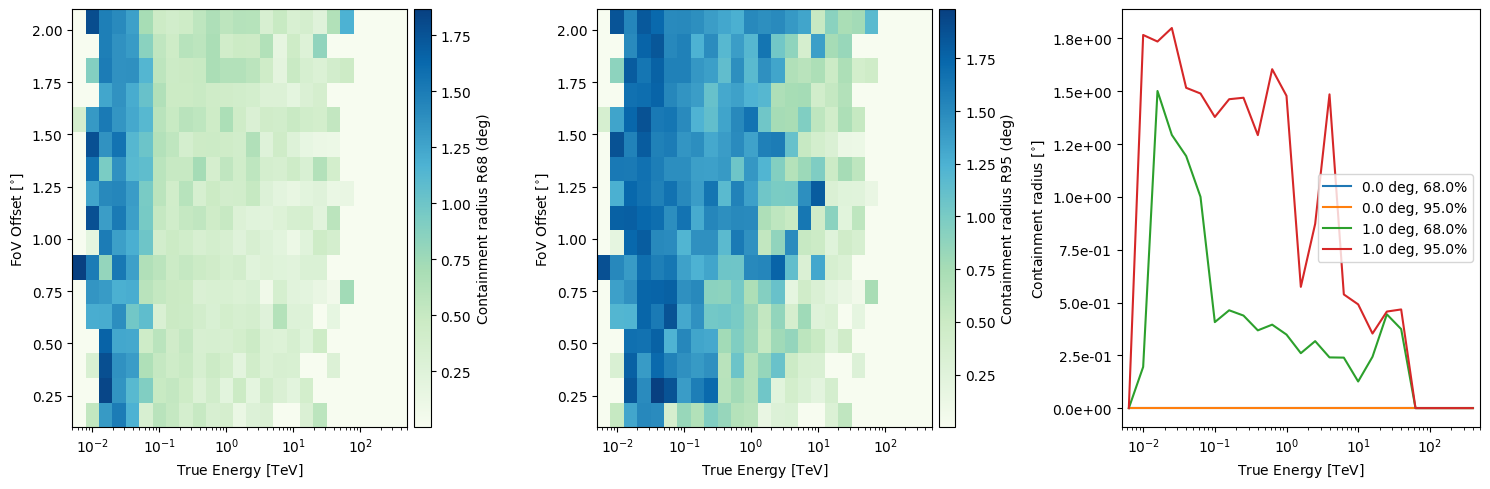

In [22]:
irf[4]['psf'].peek()

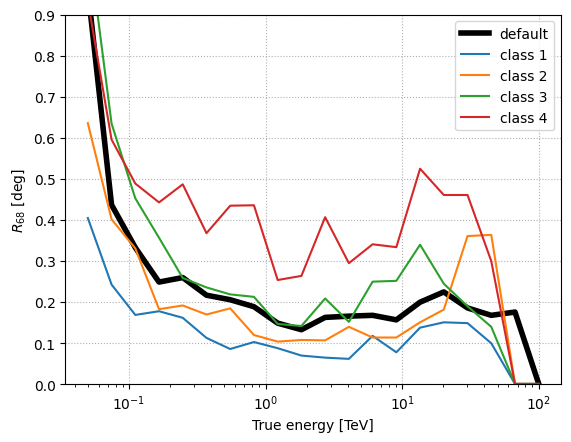

In [23]:
energy = np.geomspace(0.05, 100, num=20) * u.TeV

pyplot.semilogx()
pyplot.xlabel('True energy [TeV]')
pyplot.ylabel('$R_{68}$ [deg]')

pyplot.plot(
    energy.to('TeV').value,
    irf_ref['psf'].containment_radius(
        0.68, 
        offset=0.4*u.deg, 
        energy_true=energy
    ).to('deg').value,
    color='black',
    linewidth=4,
    label='default'
)

for evt_class in irf:
    pyplot.plot(
        energy.to('TeV').value,
        irf[evt_class]['psf'].containment_radius(
            0.68, 
            offset=0.4*u.deg, 
            energy_true=energy
        ).to('deg').value,
        label=f'class {evt_class}'
    )

pyplot.ylim(0, 0.9)
pyplot.ylim(0, None)
pyplot.grid(linestyle=':')
pyplot.legend()

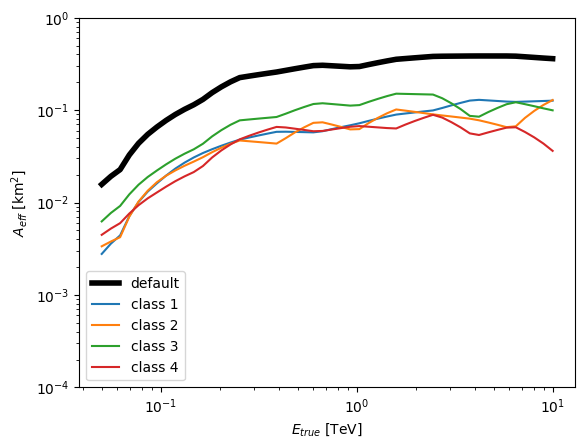

In [24]:
energy = np.geomspace(0.05, 10) * u.TeV

pyplot.loglog()
pyplot.xlabel('$E_{true}$ [TeV]')
pyplot.ylabel('$A_{eff}$ [km$^2$]')
pyplot.ylim(1e-4, 1)

pyplot.plot(
    energy.to('TeV').value,
    irf_ref['aeff'].evaluate(
        offset=0.4*u.deg, 
        energy_true=energy
    ).to('km2').value,
    color='black',
    linewidth=4,
    label='default'
)

for evt_class in irf:
    pyplot.plot(
        energy.to('TeV').value,
        irf[evt_class]['aeff'].evaluate(
            offset=0.4*u.deg, 
            energy_true=energy
        ).to('km2').value,
        label=f'class {evt_class}'
    )
    
pyplot.legend()
# pyplot.grid(linestyle=':')

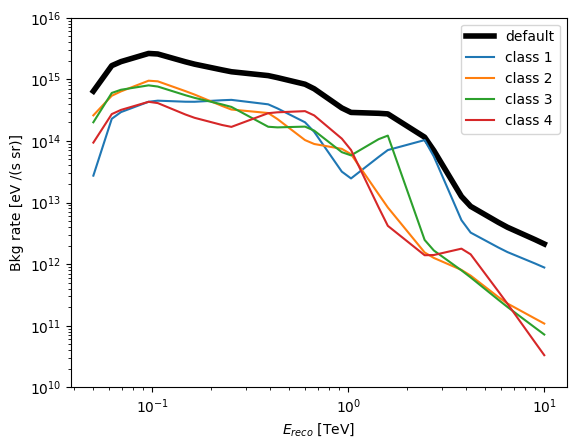

In [25]:
energy = np.geomspace(0.05, 10) * u.TeV

pyplot.loglog()
pyplot.xlabel('$E_{reco}$ [TeV]')
pyplot.ylabel('Bkg rate [eV /(s sr)]')
pyplot.ylim(1e10, 1e16)

pyplot.plot(
    energy.to('TeV').value,
    (energy**2 * irf_ref['bkg'].evaluate(
        offset=0.4*u.deg, 
        energy=energy
    )).to('eV /(s sr)').value,
    color='black',
    linewidth=4,
    label='default'
)

for evt_class in irf:
    pyplot.plot(
        energy.to('TeV').value,
        (energy**2 * irf[evt_class]['bkg'].evaluate(
            offset=0.4*u.deg, 
            energy=energy
        )).to('eV /(s sr)').value,
        label=f'class {evt_class}'
    )
    
pyplot.legend()

In [26]:
def compute_energy_resolution(edisp, energy_true, offset=0.4*u.deg, containment=0.68):
    migra = edisp.axes["migra"]
    mcenter = migra.center
#     mcenter = np.geomspace(0.1, 10, num=1000)
    resolution = np.zeros(energy_true.shape)

    for ei, energy in enumerate(energy_true):
        disp = edisp.evaluate(
            offset=offset,
            energy_true=energy,
            migra=mcenter
        )
        disp /= disp.sum()
        
        selection = np.where(
            (disp.cumsum() > 0.5 - containment/2) & (disp.cumsum() < 0.5 + containment/2)
        )
        if len(selection[0]) > 0:
            resolution[ei] = (mcenter[selection].max() - mcenter[selection].min()) / 2
        
    return resolution

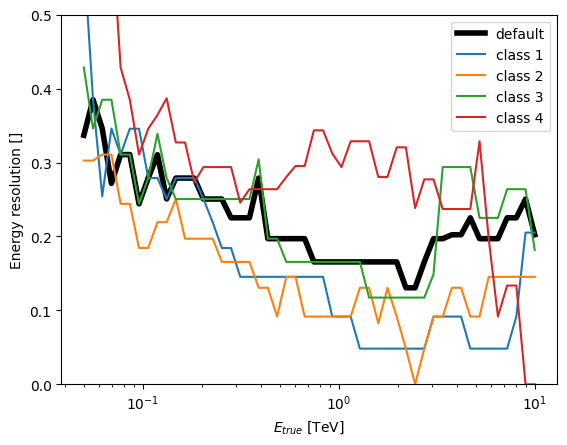

In [27]:
energy = np.geomspace(0.05, 10) * u.TeV

pyplot.semilogx()
pyplot.xlabel('$E_{true}$ [TeV]')
pyplot.ylabel('Energy resolution []')
pyplot.ylim(0.0, 0.5)

pyplot.plot(
    energy.to('TeV').value,
    compute_energy_resolution(
        irf_ref['edisp'],
        energy,
        offset=0.4*u.deg,
    ),
    color='black',
    linewidth=4,
    label='default'
)

for evt_class in irf:
    pyplot.plot(
        energy.to('TeV').value,
        compute_energy_resolution(
            irf[evt_class]['edisp'],
            energy,
            offset=0.4*u.deg,
        ),
        label=f'class {evt_class}'
    )
    
pyplot.legend()

In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt

from astropy.coordinates import Angle, SkyCoord
from regions import CircleSkyRegion
from gammapy.maps import MapAxis, WcsGeom
from gammapy.datasets import MapDatasetEventSampler

from gammapy.data import DataStore
from gammapy.datasets import (
    Datasets,
    FluxPointsDataset,
    SpectrumDataset,
    SpectrumDatasetOnOff,
)
from gammapy.estimators import FluxPointsEstimator, SensitivityEstimator
from gammapy.estimators.utils import resample_energy_edges



In [29]:
path = "/fefs/aswg/workspace/silvia.garciasoto/EVENT_TYPES/ET_LST"
frac_part = "irf-classes-MLP/processed_f-50_50_p-25_50_75/results_f-50_50_p-25_50_75"

In [67]:
energy_axis = MapAxis.from_energy_bounds(0.03 * u.TeV, 30 * u.TeV, nbin=20)


In [68]:
energy_centers = 0.5 * (energy_axis.edges[1:] + energy_axis.edges[:-1])
data = np.load(f"{path}/{frac_part}/MLP_sens_f-50_50_p-25_50_75.npz")
data_rf = np.load(f"{path}/ievgen/sens_75-25_RF.npz")


In [69]:
print(list(data.keys()))

['energy', 'energy_unit', 'sens_ref', 'sens_evcls_combined', 'sens_evcls', 'flux_unit']


In [70]:
energy = data["energy"]
sens_ref = data["sens_ref"]

sens_evcls_combined = data["sens_evcls_combined"]
sens_evcls = data["sens_evcls"]

sens_evcls_combined_rf = data_rf["sens_evcls_combined"]

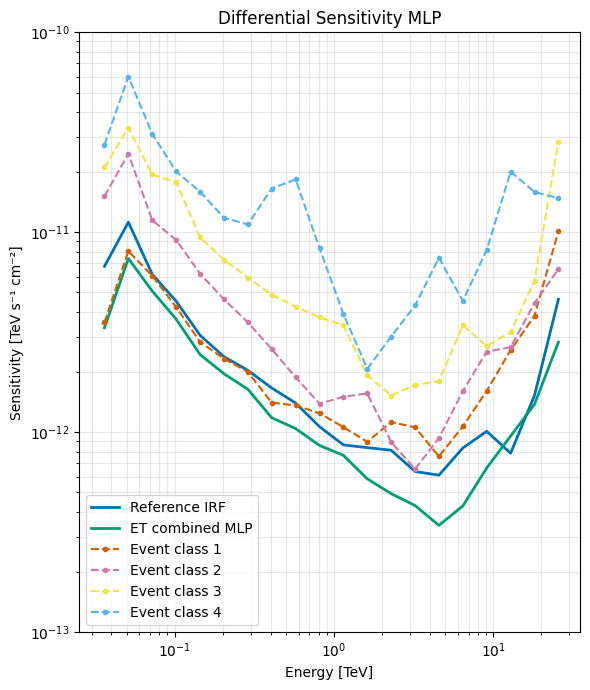

In [74]:
plt.style.use("seaborn-v0_8-colorblind")     
#plt.style.use("Solarize_Light2")   

plt.figure(figsize=(6,7))

plt.loglog(energy_centers, sens_ref, label="Reference IRF", lw=2)

plt.loglog(
    energy_centers,
    sens_evcls_combined,
    label="ET combined MLP",
    lw=2
)

for i, sens in enumerate(sens_evcls, start=1):
    plt.loglog(
        energy_centers,
        sens,
        linestyle="--",
        marker=".",
        label=f"Event class {i}"
    )

plt.xlabel(f"Energy [{energy_centers.unit}]")
plt.ylabel(f"Sensitivity [TeV s⁻¹ cm⁻²]")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("Differential Sensitivity MLP")
plt.xlim(2.5e-2, 35)
plt.ylim(1e-13, 1e-10)
plt.tight_layout()
plt.savefig("sensitivities_mlp-regressor.png")
plt.show()

/tmp/ipykernel_7150/1731343629.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


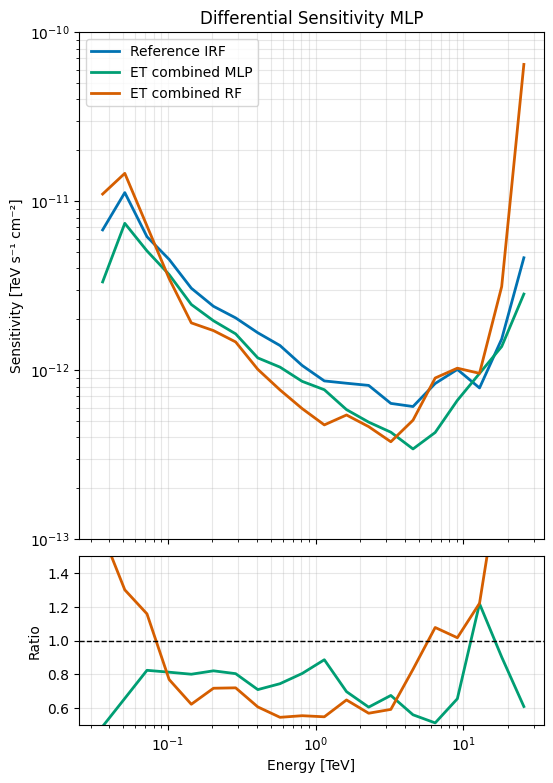

In [75]:
ratio_mlp = sens_evcls_combined / sens_ref
ratio_rf  = sens_evcls_combined_rf / sens_ref

fig, (ax, ax_ratio) = plt.subplots(
    2, 1,
    figsize=(6,9),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# ---- TOP PANEL ----
line_ref, = ax.loglog(
    energy_centers, sens_ref,
    label="Reference IRF", lw=2
)

line_mlp, = ax.loglog(
    energy_centers, sens_evcls_combined,
    label="ET combined MLP", lw=2
)

line_rf, = ax.loglog(
    energy_centers, sens_evcls_combined_rf,
    label="ET combined RF", lw=2
)

ax.set_ylabel("Sensitivity [TeV s⁻¹ cm⁻²]")
ax.set_xlim(2.5e-2, 35)
ax.set_ylim(1e-13, 1e-10)

ax.grid(True, which="both", alpha=0.3)
ax.legend()
ax.set_title("Differential Sensitivity MLP")

# ---- RATIO PANEL ----
ax_ratio.semilogx(
    energy_centers, ratio_mlp,
    color=line_mlp.get_color(),
    lw=2,
    label="MLP / Ref"
)

ax_ratio.semilogx(
    energy_centers, ratio_rf,
    color=line_rf.get_color(),
    lw=2,
    label="RF / Ref"
)

ax_ratio.axhline(1, color="black", linestyle="--", lw=1)

ax_ratio.set_xlabel(f"Energy [{energy_centers.unit}]")
ax_ratio.set_ylabel("Ratio")
ax_ratio.set_ylim(0.5, 1.5)

ax_ratio.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("sensitivities_mlp-regressor.png", dpi=300)
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord

from regions import CircleSkyRegion

# Gammapy core
from gammapy.maps import MapAxis, RegionGeom
from gammapy.data import Observation, observatory_locations
from gammapy.datasets import Datasets, SpectrumDataset
from gammapy.makers import SpectrumDatasetMaker
from gammapy.estimators import FluxPointsEstimator
from gammapy.modeling.models import (
    PowerLawSpectralModel,
    SkyModel,
    Models,
)

# CTA / IRF utilities (make sure this exists in your environment)
from gammapy.irf import load_irf_dict_from_file

# Pointing
from gammapy.data import FixedPointingInfo

# Logging
import logging
logger = logging.getLogger(__name__)

In [3]:
partitions = [
    "20_80",
    "35_65",
    "50_50",
    "15_20_65",
    "20_25_55",
    "33_33_34",
    "10_10_15_65",
    "15_15_30_40",
    "25_25_25_25",
    "20_20_20_20_20",
]

fractions = [50, 50]

In [4]:
# =========================
# Energy axes
# =========================
energy_axis = MapAxis.from_energy_bounds(
    0.03 * u.TeV, 30 * u.TeV, nbin=20
)

energy_axis_true = MapAxis.from_energy_bounds(
    0.01 * u.TeV,
    100 * u.TeV,
    nbin=100,
    name="energy_true",
)


# =========================
# Crab model
# =========================
spectral_model = PowerLawSpectralModel(index=2.62)

crab_model = SkyModel(
    spectral_model=spectral_model,
    name="Crab Nebula",
)

models = Models([crab_model])


# =========================
# Sensitivity estimator
# =========================
def get_sensitivity_ul(observations, offset, geom, on_region_radius):

    datasets = Datasets()

    for obs in observations:

        empty_dataset = SpectrumDataset.create(
            geom,
            energy_axis_true=energy_axis_true
        )

        dataset = maker.run(empty_dataset, obs)

        containment = 0.68

        dataset.exposure *= containment

        on_radii = obs.psf.containment_radius(
            energy_true=energy_axis.center,
            offset=offset * u.deg,
            fraction=containment
        )

        factor = (1 - np.cos(on_radii)) / (1 - np.cos(on_region_radius))

        dataset.background *= factor.value.reshape((-1, 1, 1))

        dataset.counts = dataset.background
        dataset.counts.data = np.floor(dataset.counts.data)

        dataset.models = models

        datasets.append(dataset)

    fpe = FluxPointsEstimator(
        energy_edges=energy_axis.edges,
        source="Crab Nebula",
        n_sigma_ul=5,
        selection_optional=["all"],
        norm_max=5e4,
    ).run(datasets)

    result = fpe.e2dnde_ul.data[:, 0, 0] * fpe.e2dnde_ul.unit

    fix_10_counts = True
    if fix_10_counts:

        back_zero = fpe.counts.data[:, 0, 0, 0] == 0
        result[back_zero] *= 10 / 12.5

    return result



In [10]:
def PPUTs(sensitivity_ets, sensitivity_no_ets):

    N = len(sensitivity_ets)

    assert N == len(sensitivity_no_ets)

    pputs = 1
    bad_bins = 0

    for i in range(N):

        ratio = sensitivity_no_ets[i] / sensitivity_ets[i]

        if ratio <= 0.4 or ratio >= 2.5:
            bad_bins += 1
        else:
            pputs *= ratio

    return pputs ** (1 / (N - bad_bins))


In [17]:
#offsets = np.arange(0.5, 4.5 + 0.1, 1)

#offsets = [0.3, 0.5, 0.7, 1.0]
offsets = np.arange(0.2, 2.2, 0.36)

location = observatory_locations["cta_north"]

livetime = 50 * u.h

maker = SpectrumDatasetMaker(
    selection=["exposure", "background", "edisp"]
)


In [18]:
irf_ref = load_irf_dict_from_file(
    "processed_f-50_50_p-25_50_75/irf.fits"
)

pointing = SkyCoord(ra=0 * u.deg, dec=0 * u.deg)

pointing_info = FixedPointingInfo(
    fixed_icrs=pointing
)

observations_ref = [
    Observation.create(
        pointing=pointing_info,
        irfs=irf_ref,
        livetime=livetime,
        location=location
    )
]


In [19]:
sens_ref = []

for offset in offsets:

    source_position = pointing.directional_offset_by(
        0 * u.deg,
        offset * u.deg
    )

    on_region_radius = 0.1 * u.deg

    on_region = CircleSkyRegion(
        source_position,
        radius=on_region_radius
    )

    geom = RegionGeom.create(
        on_region,
        axes=[energy_axis]
    )

    sens = get_sensitivity_ul(
        observations_ref,
        offset,
        geom,
        on_region_radius
    )

    sens_ref.append(sens.value)

sens_ref = np.array(sens_ref)


/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)
/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)
/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)
/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)
/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimator

In [20]:
pputs_all = {}
for part_str in partitions:
    print("Processing:", part_str)

    # Convert string to list of ints
    parts = list(map(int, part_str.split("_")))

    # Compute cumulative sums (excluding full 100)
    cumulative = []
    running_sum = 0
    for p in parts[:-1]:  # exclude last
        running_sum += p
        cumulative.append(running_sum)

    # Convert cumulative list to string
    cumulative_str = "_".join(map(str, cumulative))

    name = f"f-{'_'.join(map(str, fractions))}_p-{cumulative_str}"
    dir_name = f"processed_{name}"

    print(dir_name)

    n_classes = len(parts)
    print(n_classes, "classes")

    irfs = {
        evcls: load_irf_dict_from_file(
            f"{dir_name}/irf_MLP_class{evcls}.fits"
        )
        for evcls in range(1, n_classes + 1)
    }

    observations_evcls = [
        Observation.create(
            pointing=pointing_info,
            irfs=irfs[evcls],
            livetime=livetime,
            location=location
        )
        for evcls in range(1, n_classes + 1)
    ]

    sens_list = []

    for offset in offsets:
        print("Offset: ", offset)
        source_position = pointing.directional_offset_by(
            0 * u.deg,
            offset * u.deg
        )

        on_region_radius = 0.1 * u.deg

        on_region = CircleSkyRegion(
            source_position,
            radius=on_region_radius
        )

        geom = RegionGeom.create(
            on_region,
            axes=[energy_axis]
        )

        sens = get_sensitivity_ul(
            observations_evcls,
            offset,
            geom,
            on_region_radius
        )
        sens_list.append(sens.value)
    
    sens_array = np.array(sens_list)

    pputs = []

    for i in range(len(offsets)):

        pput = PPUTs(
            sens_array[i],
            sens_ref[i]
        )

        pputs.append(pput)

    pputs_all[part_str] = np.array(pputs)


Processing: 20_80
processed_f-50_50_p-20
2 classes
Offset:  0.2


/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)


Offset:  0.56


/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)


Offset:  0.9200000000000002


...

/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)


Offset:  1.6400000000000001


/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)


Offset:  2.0000000000000004


/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)


In [21]:
pputs_all

{'20_80': array([1.200516  , 1.21213475, 1.15058843, 1.20542769, 1.23589641,
        1.27658178]),
 '35_65': array([1.31373768, 1.22763377, 1.14631802, 1.23910377, 1.20284967,
        1.27544174]),
 '50_50': array([1.11813452, 1.16316789, 1.08637435, 1.1486448 , 1.09325048,
        1.1099398 ]),
 '15_20_65': array([1.30045921, 1.28912225, 1.23521538, 1.35437958, 1.31642908,
        1.28509619]),
 '20_25_55': array([1.26869018, 1.26967131, 1.25522453, 1.36956586, 1.23712014,
        1.23816576]),
 '33_33_34': array([1.26732728, 1.24828659, 1.1724513 , 1.30735954, 1.29561222,
        1.31418502]),
 '10_10_15_65': array([1.37818847, 1.29708399, 1.3886828 , 1.38699085, 1.34404762,
        1.44186232]),
 '15_15_30_40': array([1.44518272, 1.31104304, 1.3514992 , 1.45910251, 1.38871316,
        1.35461271]),
 '25_25_25_25': array([1.32240065, 1.24708592, 1.25394705, 1.27281823, 1.28935599,
        1.32388335]),
 '20_20_20_20_20': array([1.38205642, 1.31771568, 1.22634039, 1.34888608, 1.399353

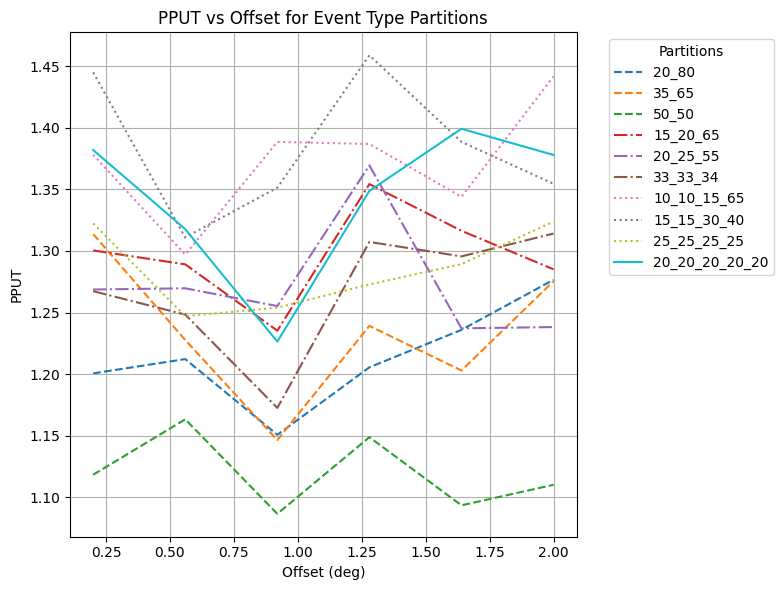

In [23]:
plt.figure(figsize=(8, 6))

for part_str in partitions:

    values = pputs_all[part_str]

    n = len(part_str.split("_"))

    if n == 2:
        linestyle = "--"
    elif n == 3:
        linestyle = "-."
    elif n == 4:
        linestyle = ":"
    else:
        linestyle = "-"

    plt.plot(
        offsets,
        values,
        label=part_str,
        linestyle=linestyle
    )

plt.xlabel("Offset (deg)")
plt.ylabel("PPUT")

plt.title("PPUT vs Offset for Event Type Partitions")

plt.grid(True)

plt.legend(
    title="Partitions",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig("MLP_PPUTs.pdf", dpi=300, bbox_inches="tight")

plt.show()